In [1]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\ZEUS\Documents\carbon_aware_marine_ai")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
EMISSIONS_DIR = OUTPUTS_DIR / "emissions"
CLOUD_SIM_DIR = OUTPUTS_DIR / "cloud_simulation"
MODELS_DIR = OUTPUTS_DIR / "models"

FIGURES_DIR = PROJECT_ROOT / "figures"

for folder in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    METRICS_DIR,
    EMISSIONS_DIR,
    CLOUD_SIM_DIR,
    MODELS_DIR,
    FIGURES_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data folder:", PROCESSED_DATA_DIR)
print("Metrics folder:", METRICS_DIR)
print("Emissions folder:", EMISSIONS_DIR)
print("Models folder:", MODELS_DIR)
print("Figures folder:", FIGURES_DIR)

Project root: C:\Users\ZEUS\Documents\carbon_aware_marine_ai
Processed data folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\processed
Metrics folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\metrics
Emissions folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\emissions
Models folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\models
Figures folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures


In [2]:
import time
import json
import random
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from codecarbon import EmissionsTracker

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Libraries loaded successfully.")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Libraries loaded successfully.
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti


In [3]:
ml_file_path = PROCESSED_DATA_DIR / "sst_ml_features_south_florida_atlantic_2021_2024.csv"

print("ML file path:")
print(ml_file_path)
print("File exists:", ml_file_path.exists())

if not ml_file_path.exists():
    raise FileNotFoundError("ML-ready CSV file was not found. Please check Notebook 03 output.")

ml_df = pd.read_csv(ml_file_path)

ml_df["time"] = pd.to_datetime(ml_df["time"])

print("Dataset loaded successfully.")
print("Shape:", ml_df.shape)
print("Date range:", ml_df["time"].min(), "to", ml_df["time"].max())
print("Unique grid cells:", ml_df["grid_id"].nunique())

ml_df.head()

ML file path:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\processed\sst_ml_features_south_florida_atlantic_2021_2024.csv
File exists: True
Dataset loaded successfully.
Shape: (46272, 21)
Date range: 2021-01-15 12:00:00 to 2024-12-30 12:00:00
Unique grid cells: 32


,time,grid_id,longitude_0_360,latitude,longitude_deg,year,month,day_of_year,month_sin,month_cos,...,day_cos,sst,sst_lag_1,sst_lag_2,sst_lag_3,sst_lag_7,sst_lag_14,sst_rolling_mean_7,sst_rolling_std_7,target_sst_next_day
0,2021-01-15 12:00:00,25.375_-79.125,280.875,25.375,-79.125,2021,1,15,0.5,0.866025,...,0.966893,23.460000,23.180000,23.369999,23.680000,23.89,23.689999,23.667143,0.283767,24.029999
1,2021-01-16 12:00:00,25.375_-79.125,280.875,25.375,-79.125,2021,1,16,0.5,0.866025,...,0.962360,24.029999,23.460000,23.180000,23.369999,23.82,23.830000,23.605714,0.273853,24.260000
2,2021-01-17 12:00:00,25.375_-79.125,280.875,25.375,-79.125,2021,1,17,0.5,0.866025,...,0.957543,24.260000,24.029999,23.460000,23.180000,23.92,23.980000,23.635714,0.310315,23.970000
3,2021-01-18 12:00:00,25.375_-79.125,280.875,25.375,-79.125,2021,1,18,0.5,0.866025,...,0.952442,23.970000,24.260000,24.029999,23.460000,23.81,24.019999,23.684285,0.380826,24.090000
4,2021-01-19 12:00:00,25.375_-79.125,280.875,25.375,-79.125,2021,1,19,0.5,0.866025,...,0.947060,24.090000,23.970000,24.260000,24.029999,23.68,23.980000,23.707142,0.394196,23.430000


In [4]:
feature_columns = [
    "latitude",
    "longitude_deg",
    "year",
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    "sst",
    "sst_lag_1",
    "sst_lag_2",
    "sst_lag_3",
    "sst_lag_7",
    "sst_lag_14",
    "sst_rolling_mean_7",
    "sst_rolling_std_7"
]

target_column = "target_sst_next_day"

missing_features = [col for col in feature_columns + [target_column] if col not in ml_df.columns]

if missing_features:
    raise ValueError(f"Missing required columns: {missing_features}")

print("Feature columns:", len(feature_columns))
print("Target column:", target_column)

Feature columns: 17
Target column: target_sst_next_day


In [5]:
train_df = ml_df[ml_df["time"] < "2024-01-01"].copy()
test_df = ml_df[ml_df["time"] >= "2024-01-01"].copy()

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training date range:", train_df["time"].min(), "to", train_df["time"].max())
print("Testing date range:", test_df["time"].min(), "to", test_df["time"].max())
print("Train grid cells:", train_df["grid_id"].nunique())
print("Test grid cells:", test_df["grid_id"].nunique())

Training rows: 34592
Testing rows: 11680
Training date range: 2021-01-15 12:00:00 to 2023-12-31 12:00:00
Testing date range: 2024-01-01 12:00:00 to 2024-12-30 12:00:00
Train grid cells: 32
Test grid cells: 32


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_output_path = MODELS_DIR / "standard_scaler_sst_features.joblib"
joblib.dump(scaler, scaler_output_path)

print("Feature scaling complete.")
print("Scaler saved to:", scaler_output_path)
print("Scaler file exists:", scaler_output_path.exists())

Feature scaling complete.
Scaler saved to: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\models\standard_scaler_sst_features.joblib
Scaler file exists: True


In [7]:
def calculate_regression_metrics(y_true, y_pred):
    """
    Calculating regression metrics for SST prediction.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }


def add_model_result(results_list, model_name, y_true, y_pred, training_time_seconds, emissions_kg):
    """
    Adding one model result into the results list.
    """
    metrics = calculate_regression_metrics(y_true, y_pred)

    results_list.append({
        "model": model_name,
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "r2": metrics["r2"],
        "training_time_seconds": training_time_seconds,
        "emissions_kg_co2eq": emissions_kg
    })

    print(f"{model_name} results")
    print("-" * 40)
    print("MAE:", round(metrics["mae"], 6))
    print("RMSE:", round(metrics["rmse"], 6))
    print("R²:", round(metrics["r2"], 6))
    print("Training time seconds:", round(training_time_seconds, 3))
    print("Emissions kg CO2eq:", emissions_kg)
    print()

In [8]:
def start_tracker(model_name):
    """
    Starting a CodeCarbon tracker with safe absolute output paths.
    """
    safe_model_name = model_name.lower().replace(" ", "_").replace("/", "_")

    tracker = EmissionsTracker(
        project_name=f"marine_carbon_ai_{safe_model_name}",
        output_dir=str(EMISSIONS_DIR),
        output_file=f"emissions_{safe_model_name}.csv",
        log_level="error"
    )

    tracker.start()

    return tracker

In [9]:
model_results = []
prediction_frames = []

print("Model result storage initialized.")

Model result storage initialized.


In [10]:
start_time = time.perf_counter()

persistence_predictions = test_df["sst"].values

end_time = time.perf_counter()

persistence_time = end_time - start_time
persistence_emissions = 0.0

add_model_result(
    results_list=model_results,
    model_name="Persistence_Baseline",
    y_true=y_test,
    y_pred=persistence_predictions,
    training_time_seconds=persistence_time,
    emissions_kg=persistence_emissions
)

prediction_frames.append(pd.DataFrame({
    "time": test_df["time"].values,
    "grid_id": test_df["grid_id"].values,
    "actual_sst": y_test.values,
    "predicted_sst": persistence_predictions,
    "model": "Persistence_Baseline"
}))

Persistence_Baseline results
----------------------------------------
MAE: 0.108254
RMSE: 0.145137
R²: 0.994993
Training time seconds: 0.0
Emissions kg CO2eq: 0.0



In [11]:
ridge_model = Ridge(alpha=1.0, random_state=RANDOM_SEED)

tracker = start_tracker("Ridge_Regression")

start_time = time.perf_counter()

ridge_model.fit(X_train_scaled, y_train)

ridge_training_time = time.perf_counter() - start_time
ridge_emissions = tracker.stop()

ridge_predictions = ridge_model.predict(X_test_scaled)

ridge_model_path = MODELS_DIR / "ridge_regression_sst_model.joblib"
joblib.dump(ridge_model, ridge_model_path)

add_model_result(
    results_list=model_results,
    model_name="Ridge_Regression",
    y_true=y_test,
    y_pred=ridge_predictions,
    training_time_seconds=ridge_training_time,
    emissions_kg=ridge_emissions
)

prediction_frames.append(pd.DataFrame({
    "time": test_df["time"].values,
    "grid_id": test_df["grid_id"].values,
    "actual_sst": y_test.values,
    "predicted_sst": ridge_predictions,
    "model": "Ridge_Regression"
}))

print("Ridge model saved to:", ridge_model_path)
print("File exists:", ridge_model_path.exists())

[codecarbon WARNING @ 18:13:29] Multiple instances of codecarbon are allowed to run at the same time.


Ridge_Regression results
----------------------------------------
MAE: 0.098404
RMSE: 0.133645
R²: 0.995755
Training time seconds: 0.004
Emissions kg CO2eq: 6.716941176841729e-06

Ridge model saved to: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\models\ridge_regression_sst_model.joblib
File exists: True


In [12]:
random_forest_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

tracker = start_tracker("Random_Forest")

start_time = time.perf_counter()

random_forest_model.fit(X_train, y_train)

rf_training_time = time.perf_counter() - start_time
rf_emissions = tracker.stop()

rf_predictions = random_forest_model.predict(X_test)

rf_model_path = MODELS_DIR / "random_forest_sst_model.joblib"
joblib.dump(random_forest_model, rf_model_path)

add_model_result(
    results_list=model_results,
    model_name="Random_Forest",
    y_true=y_test,
    y_pred=rf_predictions,
    training_time_seconds=rf_training_time,
    emissions_kg=rf_emissions
)

prediction_frames.append(pd.DataFrame({
    "time": test_df["time"].values,
    "grid_id": test_df["grid_id"].values,
    "actual_sst": y_test.values,
    "predicted_sst": rf_predictions,
    "model": "Random_Forest"
}))

print("Random Forest model saved to:", rf_model_path)
print("File exists:", rf_model_path.exists())

Random_Forest results
----------------------------------------
MAE: 0.111861
RMSE: 0.15292
R²: 0.994442
Training time seconds: 2.084
Emissions kg CO2eq: 3.844818696995742e-05

Random Forest model saved to: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\models\random_forest_sst_model.joblib
File exists: True


In [13]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

tracker = start_tracker("XGBoost")

start_time = time.perf_counter()

xgb_model.fit(X_train, y_train)

xgb_training_time = time.perf_counter() - start_time
xgb_emissions = tracker.stop()

xgb_predictions = xgb_model.predict(X_test)

xgb_model_path = MODELS_DIR / "xgboost_sst_model.joblib"
joblib.dump(xgb_model, xgb_model_path)

add_model_result(
    results_list=model_results,
    model_name="XGBoost",
    y_true=y_test,
    y_pred=xgb_predictions,
    training_time_seconds=xgb_training_time,
    emissions_kg=xgb_emissions
)

prediction_frames.append(pd.DataFrame({
    "time": test_df["time"].values,
    "grid_id": test_df["grid_id"].values,
    "actual_sst": y_test.values,
    "predicted_sst": xgb_predictions,
    "model": "XGBoost"
}))

print("XGBoost model saved to:", xgb_model_path)
print("File exists:", xgb_model_path.exists())

XGBoost results
----------------------------------------
MAE: 0.118211
RMSE: 0.16221
R²: 0.993746
Training time seconds: 0.294
Emissions kg CO2eq: 1.0431503912523652e-05

XGBoost model saved to: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\models\xgboost_sst_model.joblib
File exists: True


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Creating validation split from the training period
nn_train_df = train_df[train_df["time"] < "2023-07-01"].copy()
nn_val_df = train_df[train_df["time"] >= "2023-07-01"].copy()

X_nn_train = scaler.transform(nn_train_df[feature_columns])
y_nn_train = nn_train_df[target_column].values

X_nn_val = scaler.transform(nn_val_df[feature_columns])
y_nn_val = nn_val_df[target_column].values

X_nn_test = X_test_scaled
y_nn_test = y_test.values

X_nn_train_tensor = torch.tensor(X_nn_train, dtype=torch.float32)
y_nn_train_tensor = torch.tensor(y_nn_train, dtype=torch.float32).view(-1, 1)

X_nn_val_tensor = torch.tensor(X_nn_val, dtype=torch.float32)
y_nn_val_tensor = torch.tensor(y_nn_val, dtype=torch.float32).view(-1, 1)

X_nn_test_tensor = torch.tensor(X_nn_test, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_nn_train_tensor, y_nn_train_tensor)
val_dataset = TensorDataset(X_nn_val_tensor, y_nn_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2048, shuffle=False)

print("PyTorch device:", device)
print("Neural network train rows:", len(nn_train_df))
print("Neural network validation rows:", len(nn_val_df))
print("Neural network test rows:", len(test_df))

PyTorch device: cuda
Neural network train rows: 28704
Neural network validation rows: 5888
Neural network test rows: 11680


In [15]:
class SSTNeuralNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


input_dim = len(feature_columns)

nn_model = SSTNeuralNetwork(input_dim=input_dim).to(device)

loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001, weight_decay=1e-5)

print(nn_model)

SSTNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [16]:
tracker = start_tracker("PyTorch_Neural_Network")

start_time = time.perf_counter()

num_epochs = 120
patience = 15

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

training_history = []

for epoch in range(1, num_epochs + 1):
    nn_model.train()

    train_losses = []

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        predictions = nn_model(batch_X)
        loss = loss_function(predictions, batch_y)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    nn_model.eval()

    val_losses = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            val_predictions = nn_model(batch_X)
            val_loss = loss_function(val_predictions, batch_y)

            val_losses.append(val_loss.item())

    avg_train_loss = float(np.mean(train_losses))
    avg_val_loss = float(np.mean(val_losses))

    training_history.append({
        "epoch": epoch,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss
    })

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = nn_model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {avg_train_loss:.6f} | "
            f"Val Loss: {avg_val_loss:.6f}"
        )

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}.")
        break

nn_training_time = time.perf_counter() - start_time
nn_emissions = tracker.stop()

if best_model_state is not None:
    nn_model.load_state_dict(best_model_state)

print("Neural network training complete.")
print("Training time seconds:", round(nn_training_time, 3))
print("Estimated emissions kg CO2eq:", nn_emissions)

Epoch 001 | Train Loss: 727.577273 | Val Loss: 724.552409
Epoch 010 | Train Loss: 6.571337 | Val Loss: 6.274038
Epoch 020 | Train Loss: 4.289527 | Val Loss: 2.821084
Epoch 030 | Train Loss: 3.763509 | Val Loss: 1.404452
Epoch 040 | Train Loss: 3.337659 | Val Loss: 1.512169
Epoch 050 | Train Loss: 3.052321 | Val Loss: 1.134539
Epoch 060 | Train Loss: 2.689241 | Val Loss: 0.793542
Early stopping at epoch 62.
Neural network training complete.
Training time seconds: 10.034
Estimated emissions kg CO2eq: 0.00010430960646233755


In [17]:
nn_model.eval()

with torch.no_grad():
    nn_predictions = nn_model(X_nn_test_tensor).cpu().numpy().flatten()

nn_model_path = MODELS_DIR / "pytorch_neural_network_sst_model.pt"
torch.save(nn_model.state_dict(), nn_model_path)

training_history_df = pd.DataFrame(training_history)
training_history_path = METRICS_DIR / "pytorch_neural_network_training_history.csv"
training_history_df.to_csv(training_history_path, index=False)

add_model_result(
    results_list=model_results,
    model_name="PyTorch_Neural_Network",
    y_true=y_test,
    y_pred=nn_predictions,
    training_time_seconds=nn_training_time,
    emissions_kg=nn_emissions
)

prediction_frames.append(pd.DataFrame({
    "time": test_df["time"].values,
    "grid_id": test_df["grid_id"].values,
    "actual_sst": y_test.values,
    "predicted_sst": nn_predictions,
    "model": "PyTorch_Neural_Network"
}))

print("Neural network model saved to:", nn_model_path)
print("Model file exists:", nn_model_path.exists())

print("Training history saved to:", training_history_path)
print("History file exists:", training_history_path.exists())

PyTorch_Neural_Network results
----------------------------------------
MAE: 0.727307
RMSE: 0.910292
R²: 0.803057
Training time seconds: 10.034
Emissions kg CO2eq: 0.00010430960646233755

Neural network model saved to: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\models\pytorch_neural_network_sst_model.pt
Model file exists: True
Training history saved to: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\metrics\pytorch_neural_network_training_history.csv
History file exists: True


In [18]:
model_metrics_df = pd.DataFrame(model_results)

model_metrics_df = model_metrics_df.sort_values("rmse").reset_index(drop=True)

metrics_output_path = METRICS_DIR / "model_metrics_south_florida_atlantic_2021_2024.csv"

model_metrics_df.to_csv(metrics_output_path, index=False)

print("Model metrics saved to:")
print(metrics_output_path)
print("File exists:", metrics_output_path.exists())

model_metrics_df

Model metrics saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\metrics\model_metrics_south_florida_atlantic_2021_2024.csv
File exists: True


,model,mae,rmse,r2,training_time_seconds,emissions_kg_co2eq
0,Ridge_Regression,0.098404,0.133645,0.995755,0.003660,0.000007
1,Persistence_Baseline,0.108254,0.145137,0.994993,0.000221,0.000000
2,Random_Forest,0.111861,0.152920,0.994442,2.084318,0.000038
3,XGBoost,0.118211,0.162210,0.993746,0.294449,0.000010
4,PyTorch_Neural_Network,0.727307,0.910292,0.803057,10.034340,0.000104


In [19]:
all_predictions_df = pd.concat(prediction_frames, ignore_index=True)

all_predictions_output_path = METRICS_DIR / "model_predictions_south_florida_atlantic_2024.csv"

all_predictions_df.to_csv(all_predictions_output_path, index=False)

print("All model predictions saved to:")
print(all_predictions_output_path)
print("File exists:", all_predictions_output_path.exists())
print("Shape:", all_predictions_df.shape)

all_predictions_df.head()

All model predictions saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\metrics\model_predictions_south_florida_atlantic_2024.csv
File exists: True
Shape: (58400, 5)


,time,grid_id,actual_sst,predicted_sst,model
0,2024-01-01 12:00:00,25.375_-79.125,23.449999,23.260000,Persistence_Baseline
1,2024-01-02 12:00:00,25.375_-79.125,23.560000,23.449999,Persistence_Baseline
2,2024-01-03 12:00:00,25.375_-79.125,23.600000,23.560000,Persistence_Baseline
3,2024-01-04 12:00:00,25.375_-79.125,23.560000,23.600000,Persistence_Baseline
4,2024-01-05 12:00:00,25.375_-79.125,23.460000,23.560000,Persistence_Baseline


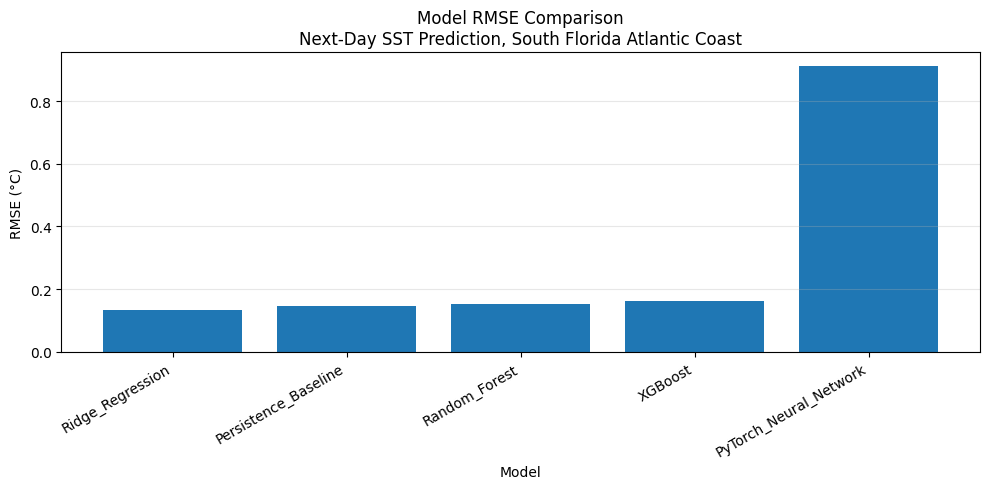

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\model_rmse_comparison_south_florida_atlantic.png
File exists: True


In [20]:
plt.figure(figsize=(10, 5))

plt.bar(model_metrics_df["model"], model_metrics_df["rmse"])

plt.title("Model RMSE Comparison\nNext-Day SST Prediction, South Florida Atlantic Coast")
plt.xlabel("Model")
plt.ylabel("RMSE (°C)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "model_rmse_comparison_south_florida_atlantic.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

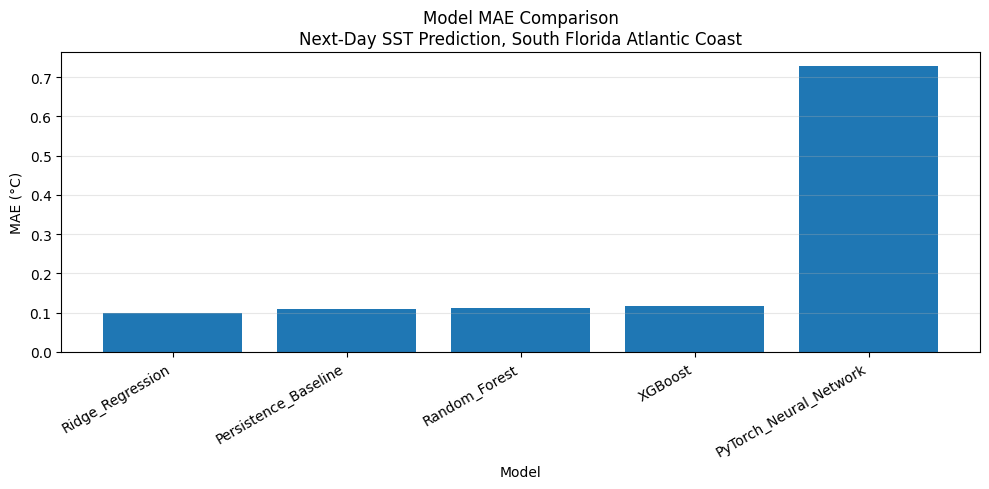

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\model_mae_comparison_south_florida_atlantic.png
File exists: True


In [21]:
plt.figure(figsize=(10, 5))

plt.bar(model_metrics_df["model"], model_metrics_df["mae"])

plt.title("Model MAE Comparison\nNext-Day SST Prediction, South Florida Atlantic Coast")
plt.xlabel("Model")
plt.ylabel("MAE (°C)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "model_mae_comparison_south_florida_atlantic.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

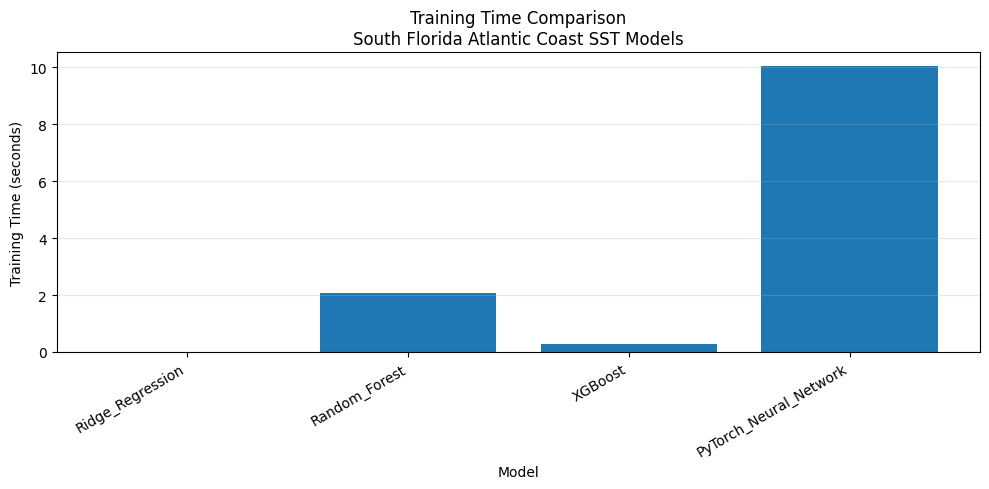

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\model_training_time_comparison_south_florida_atlantic.png
File exists: True


In [22]:
training_models_df = model_metrics_df[model_metrics_df["model"] != "Persistence_Baseline"].copy()

plt.figure(figsize=(10, 5))

plt.bar(training_models_df["model"], training_models_df["training_time_seconds"])

plt.title("Training Time Comparison\nSouth Florida Atlantic Coast SST Models")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "model_training_time_comparison_south_florida_atlantic.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

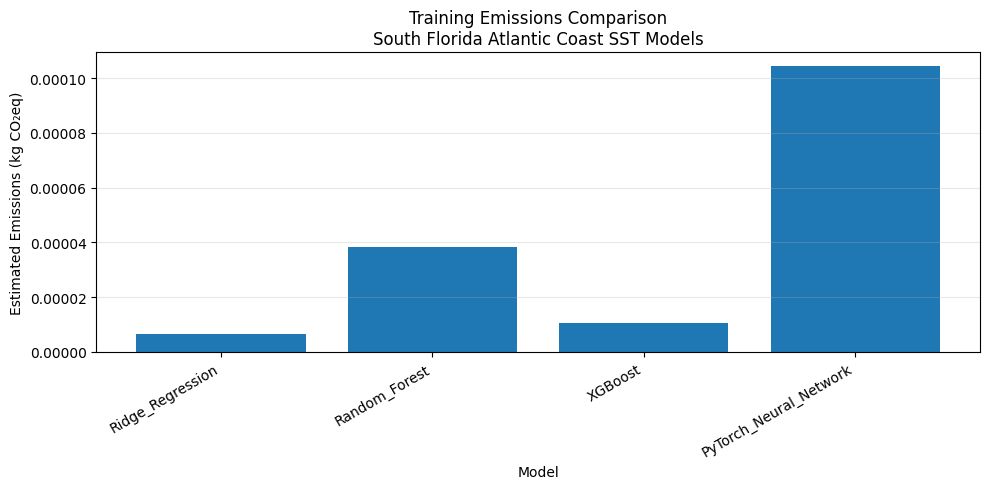

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\model_training_emissions_comparison_south_florida_atlantic.png
File exists: True


In [23]:
plt.figure(figsize=(10, 5))

plt.bar(training_models_df["model"], training_models_df["emissions_kg_co2eq"])

plt.title("Training Emissions Comparison\nSouth Florida Atlantic Coast SST Models")
plt.xlabel("Model")
plt.ylabel("Estimated Emissions (kg CO₂eq)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "model_training_emissions_comparison_south_florida_atlantic.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

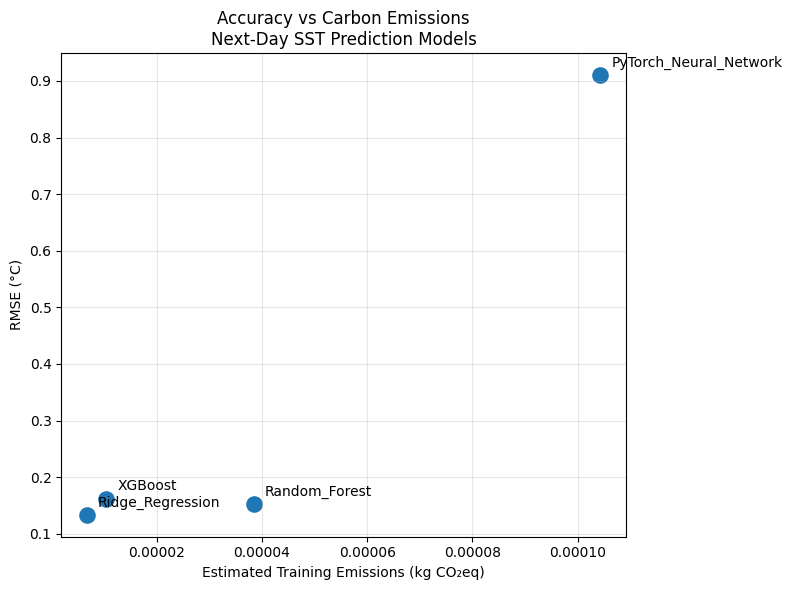

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\accuracy_vs_emissions_south_florida_atlantic.png
File exists: True


In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    training_models_df["emissions_kg_co2eq"],
    training_models_df["rmse"],
    s=120
)

for _, row in training_models_df.iterrows():
    plt.annotate(
        row["model"],
        (row["emissions_kg_co2eq"], row["rmse"]),
        textcoords="offset points",
        xytext=(8, 6),
        ha="left"
    )

plt.title("Accuracy vs Carbon Emissions\nNext-Day SST Prediction Models")
plt.xlabel("Estimated Training Emissions (kg CO₂eq)")
plt.ylabel("RMSE (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "accuracy_vs_emissions_south_florida_atlantic.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

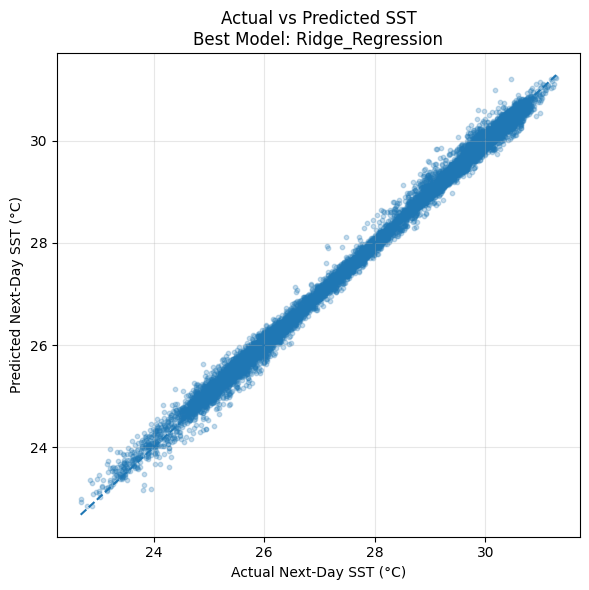

Best model: Ridge_Regression
Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\actual_vs_predicted_best_model_south_florida_atlantic.png
File exists: True


In [25]:
best_model_name = model_metrics_df.iloc[0]["model"]

best_predictions_df = all_predictions_df[
    all_predictions_df["model"] == best_model_name
].copy()

plt.figure(figsize=(6, 6))

plt.scatter(
    best_predictions_df["actual_sst"],
    best_predictions_df["predicted_sst"],
    alpha=0.25,
    s=10
)

min_value = min(best_predictions_df["actual_sst"].min(), best_predictions_df["predicted_sst"].min())
max_value = max(best_predictions_df["actual_sst"].max(), best_predictions_df["predicted_sst"].max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.title(f"Actual vs Predicted SST\nBest Model: {best_model_name}")
plt.xlabel("Actual Next-Day SST (°C)")
plt.ylabel("Predicted Next-Day SST (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "actual_vs_predicted_best_model_south_florida_atlantic.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Best model:", best_model_name)
print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

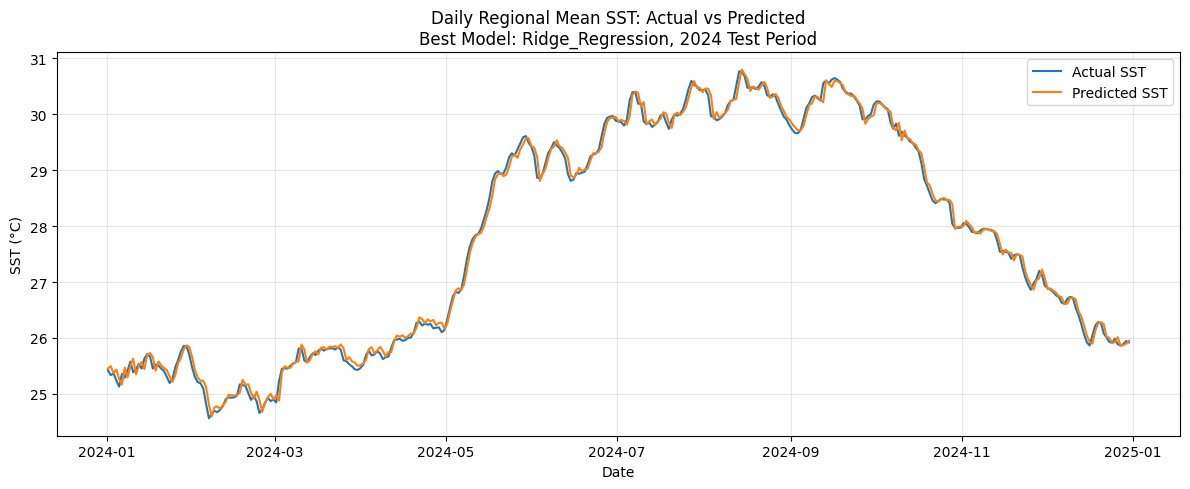

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\daily_actual_vs_predicted_best_model_2024_south_florida_atlantic.png
File exists: True


In [26]:
best_daily_df = (
    best_predictions_df
    .groupby("time", as_index=False)
    .agg(
        actual_sst=("actual_sst", "mean"),
        predicted_sst=("predicted_sst", "mean")
    )
)

plt.figure(figsize=(12, 5))

plt.plot(best_daily_df["time"], best_daily_df["actual_sst"], label="Actual SST")
plt.plot(best_daily_df["time"], best_daily_df["predicted_sst"], label="Predicted SST")

plt.title(f"Daily Regional Mean SST: Actual vs Predicted\nBest Model: {best_model_name}, 2024 Test Period")
plt.xlabel("Date")
plt.ylabel("SST (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "daily_actual_vs_predicted_best_model_2024_south_florida_atlantic.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

In [27]:
best_row = model_metrics_df.iloc[0].to_dict()

experiment_summary = {
    "project_title": "Carbon-Aware Cloud Computing for AI in Marine Research",
    "case_study_region": "South Florida Atlantic Coast",
    "task": "Next-day sea surface temperature prediction",
    "training_period": "2021-01-15 to 2023-12-31",
    "testing_period": "2024-01-01 to 2024-12-30",
    "training_rows": len(train_df),
    "testing_rows": len(test_df),
    "feature_count": len(feature_columns),
    "models_trained": ", ".join(model_metrics_df["model"].tolist()),
    "best_model_by_rmse": best_row["model"],
    "best_model_rmse": best_row["rmse"],
    "best_model_mae": best_row["mae"],
    "best_model_r2": best_row["r2"],
    "best_model_emissions_kg_co2eq": best_row["emissions_kg_co2eq"],
}

experiment_summary_df = pd.DataFrame([experiment_summary])

summary_output_path = OUTPUTS_DIR / "training_experiment_summary_south_florida_atlantic_2021_2024.csv"

experiment_summary_df.to_csv(summary_output_path, index=False)

print("Training experiment summary saved to:")
print(summary_output_path)
print("File exists:", summary_output_path.exists())

experiment_summary_df

Training experiment summary saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\training_experiment_summary_south_florida_atlantic_2021_2024.csv
File exists: True


,project_title,case_study_region,task,training_period,testing_period,training_rows,testing_rows,feature_count,models_trained,best_model_by_rmse,best_model_rmse,best_model_mae,best_model_r2,best_model_emissions_kg_co2eq
0,Carbon-Aware Cloud Computing for AI in Marine ...,South Florida Atlantic Coast,Next-day sea surface temperature prediction,2021-01-15 to 2023-12-31,2024-01-01 to 2024-12-30,34592,11680,17,"Ridge_Regression, Persistence_Baseline, Random...",Ridge_Regression,0.133645,0.098404,0.995755,0.000007


In [28]:
# Creating clearer emissions units for reporting

model_metrics_df["emissions_g_co2eq"] = model_metrics_df["emissions_kg_co2eq"] * 1000
model_metrics_df["emissions_mg_co2eq"] = model_metrics_df["emissions_kg_co2eq"] * 1_000_000

# Calculating improvement over persistence baseline
persistence_rmse = model_metrics_df.loc[
    model_metrics_df["model"] == "Persistence_Baseline",
    "rmse"
].iloc[0]

model_metrics_df["rmse_improvement_vs_persistence_percent"] = (
    (persistence_rmse - model_metrics_df["rmse"]) / persistence_rmse
) * 100

# Saving updated metrics
metrics_output_path = METRICS_DIR / "model_metrics_south_florida_atlantic_2021_2024.csv"
model_metrics_df.to_csv(metrics_output_path, index=False)

print("Updated model metrics saved to:")
print(metrics_output_path)
print("File exists:", metrics_output_path.exists())

model_metrics_df

Updated model metrics saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\metrics\model_metrics_south_florida_atlantic_2021_2024.csv
File exists: True


,model,mae,rmse,r2,training_time_seconds,emissions_kg_co2eq,emissions_g_co2eq,emissions_mg_co2eq,rmse_improvement_vs_persistence_percent
0,Ridge_Regression,0.098404,0.133645,0.995755,0.003660,0.000007,0.006717,6.716941,7.918419
1,Persistence_Baseline,0.108254,0.145137,0.994993,0.000221,0.000000,0.000000,0.000000,0.000000
2,Random_Forest,0.111861,0.152920,0.994442,2.084318,0.000038,0.038448,38.448187,-5.362477
3,XGBoost,0.118211,0.162210,0.993746,0.294449,0.000010,0.010432,10.431504,-11.763159
4,PyTorch_Neural_Network,0.727307,0.910292,0.803057,10.034340,0.000104,0.104310,104.309606,-527.192698
